<a href="https://colab.research.google.com/github/Toiati-salah-eddine-001/Deep_Learning_G/blob/main/Pre_trained_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from tensorflow.keras.applications import EfficientNetV2L

model = EfficientNetV2L(weights='imagenet',
                        include_top=False,
                        input_shape=(224,224,3))
model.summary()

Model: "efficientnetv2-l"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      9,216 │ stem_activation[… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │        128 │ block1a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 32)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      9,216 │ block1a_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │        128 │ block1b_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 32)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_co… │ (None, 112, 112,  │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_bn  │ (None, 112, 112,  │        128 │ block1c_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_ac… │ (None, 112, 112,  │          0 │ block1c_project_

 Total params: 117,746,848 (449.17 MB)

 Trainable params: 117,234,272 (447.21 MB)

 Non-trainable params: 512,576 (1.96 MB)

In [5]:
# model.trainable=False
# or
for layer in model.layers:
  layer.trainable=False

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

my_model=Sequential([model,
                     GlobalAveragePooling2D(),
                     Dense(512,activation='relu'),
                     Dropout(0.2),
                     Dense(512,activation='relu'),
                     Dropout(0.2),
                     Dense(1,activation='sigmoid'),

])
my_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)   │ (None, 7, 7, 1280)     │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,665,889 (452.67 MB)

 Trainable params: 919,041 (3.51 MB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [12]:
!pip install -q kaggle


In [14]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"salahedddev","key":"6eec88a566611c87ea87f2ddb1e0f3b6"}'}

In [16]:
!ls -la /root

total 76
drwx------ 1 root root 4096 May 10 17:55 .
drwxr-xr-x 1 root root 4096 May 10 16:09 ..
-r-xr-xr-x 1 root root 1071 Jan  1  2000 .bashrc
drwxr-xr-x 1 root root 4096 May  6 13:37 .cache
drwxr-xr-x 1 root root 4096 May  6 13:37 .config
drwxr-xr-x 5 root root 4096 May  6 13:36 .ipython
drwxr-xr-x 1 root root 4096 May  6 13:14 .julia
drwx------ 1 root root 4096 May  6 13:36 .jupyter
drwxr-xr-x 2 root root 4096 May 10 17:55 .kaggle
drwxr-xr-x 3 root root 4096 May 10 17:10 .keras
drwx------ 3 root root 4096 May  6 13:09 .launchpadlib
drwxr-xr-x 1 root root 4096 May  6 13:14 .local
drwxr-xr-x 4 root root 4096 May  6 13:36 .npm
-rw-r--r-- 1 root root  161 Jul  9  2019 .profile
-r-xr-xr-x 1 root root  254 Jan  1  2000 .tmux.conf
-rw-r--r-- 1 root root  211 May  6 13:36 .wget-hsts


In [17]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [18]:
%cd /root/.kaggle

/root/.kaggle


In [19]:
!ls -la

total 16
drwxr-xr-x 2 root root 4096 May 10 17:55 .
drwx------ 1 root root 4096 May 10 17:55 ..
-rw------- 1 root root   67 May 10 18:14 kaggle.json


In [22]:
!kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                  Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          23057        488                1  
sharmajicoder/gen-z-social-media-usage-dataset                  Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           2647         61                1  
nalisha/gaming-vs-academic-performance                          Gaming vs Academic Performance                          228280  2026-04-27 16:10:09.720000            597         23                1  


In [23]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:13<00:00, 87.6MB/s]



In [24]:
!ls -la

total 1116028
drwxr-xr-x 2 root root       4096 May 10 18:22 .
drwx------ 1 root root       4096 May 10 17:55 ..
-rw-r--r-- 1 root root 1142791694 Oct 13  2019 dogsvscats.zip
-rw------- 1 root root         67 May 10 18:14 kaggle.json


In [25]:
!unzip dogsvscats.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/dogs/dog.4419.jpg  
  inflating: train/dogs/dog.442.jpg  
  inflating: train/dogs/dog.4420.jpg  
  inflating: train/dogs/dog.4421.jpg  
  inflating: train/dogs/dog.4422.jpg  
  inflating: train/dogs/dog.4424.jpg  
  inflating: train/dogs/dog.4425.jpg  
  inflating: train/dogs/dog.4426.jpg  
  inflating: train/dogs/dog.4427.jpg  
  inflating: train/dogs/dog.4431.jpg  
  inflating: train/dogs/dog.4433.jpg  
  inflating: train/dogs/dog.4436.jpg  
  inflating: train/dogs/dog.4438.jpg  
  inflating: train/dogs/dog.4439.jpg  
  inflating: train/dogs/dog.444.jpg  
  inflating: train/dogs/dog.4440.jpg  
  inflating: train/dogs/dog.4441.jpg  
  inflating: train/dogs/dog.4442.jpg  
  inflating: train/dogs/dog.4443.jpg  
  inflating: train/dogs/dog.4444.jpg  
  inflating: train/dogs/dog.4445.jpg  
  inflating: train/dogs/dog.4446.jpg  
  inflating: train/dogs/dog.445.jpg  
  inflating: train/dogs/dog.4450.jpg  
  inflating: tra

In [26]:
!ls -la

total 1116040
drwxr-xr-x 5 root root       4096 May 10 18:25 .
drwx------ 1 root root       4096 May 10 17:55 ..
drwxr-xr-x 4 root root       4096 May 10 18:24 catsvsdogs
-rw-r--r-- 1 root root 1142791694 Oct 13  2019 dogsvscats.zip
-rw------- 1 root root         67 May 10 18:14 kaggle.json
drwxr-xr-x 4 root root       4096 May 10 18:25 test
drwxr-xr-x 4 root root       4096 May 10 18:25 train


In [38]:
import os

try:
  os.makedirs('images')
except FileExistsError:
  pass

try:
  os.makedirs(os.path.join('images','cats'),exist_ok=True)
except FileExistsError:
  pass
try:
  os.makedirs(os.path.join('images','dogs'))
except FileExistsError:
  pass



In [39]:
!pwd

/root/.kaggle


In [40]:
!ls -la

total 1116044
drwxr-xr-x 6 root root       4096 May 10 18:35 .
drwx------ 1 root root       4096 May 10 17:55 ..
drwxr-xr-x 4 root root       4096 May 10 18:24 catsvsdogs
-rw-r--r-- 1 root root 1142791694 Oct 13  2019 dogsvscats.zip
drwxr-xr-x 4 root root       4096 May 10 18:43 images
-rw------- 1 root root         67 May 10 18:14 kaggle.json
drwxr-xr-x 4 root root       4096 May 10 18:25 test
drwxr-xr-x 4 root root       4096 May 10 18:25 train


In [41]:
!dir

catsvsdogs  dogsvscats.zip  images  kaggle.json  test  train


In [42]:
!ls images

cats  dogs


In [43]:
!ls images/cats/

In [48]:
!pwd
!ls -la

/root/.kaggle
total 1116044
drwxr-xr-x 6 root root       4096 May 10 18:35 .
drwx------ 1 root root       4096 May 10 17:55 ..
drwxr-xr-x 4 root root       4096 May 10 18:24 catsvsdogs
-rw-r--r-- 1 root root 1142791694 Oct 13  2019 dogsvscats.zip
drwxr-xr-x 4 root root       4096 May 10 18:43 images
-rw------- 1 root root         67 May 10 18:14 kaggle.json
drwxr-xr-x 4 root root       4096 May 10 18:25 test
drwxr-xr-x 4 root root       4096 May 10 18:25 train


In [52]:
!ls train/cats

cat.0.jpg      cat.12234.jpg  cat.3241.jpg  cat.549.jpg   cat.7757.jpg
cat.10002.jpg  cat.12235.jpg  cat.3243.jpg  cat.5500.jpg  cat.7758.jpg
cat.10003.jpg  cat.12236.jpg  cat.3244.jpg  cat.5502.jpg  cat.775.jpg
cat.10004.jpg  cat.12237.jpg  cat.3245.jpg  cat.5503.jpg  cat.7760.jpg
cat.10005.jpg  cat.12239.jpg  cat.3246.jpg  cat.5504.jpg  cat.7761.jpg
cat.10006.jpg  cat.1223.jpg   cat.3247.jpg  cat.5505.jpg  cat.7762.jpg
cat.10008.jpg  cat.12240.jpg  cat.3248.jpg  cat.5506.jpg  cat.7763.jpg
cat.10009.jpg  cat.12241.jpg  cat.324.jpg   cat.5507.jpg  cat.7764.jpg
cat.1000.jpg   cat.12242.jpg  cat.3250.jpg  cat.5508.jpg  cat.7765.jpg
cat.10010.jpg  cat.12244.jpg  cat.3251.jpg  cat.550.jpg   cat.7766.jpg
cat.10011.jpg  cat.12245.jpg  cat.3252.jpg  cat.5510.jpg  cat.7767.jpg
cat.10012.jpg  cat.12246.jpg  cat.3253.jpg  cat.5512.jpg  cat.7768.jpg
cat.10013.jpg  cat.12247.jpg  cat.3254.jpg  cat.5513.jpg  cat.7769.jpg
cat.10014.jpg  cat.12248.jpg  cat.3255.jpg  cat.5514.jpg  cat.7770.jpg
cat.100

In [53]:
# import shutil

# for filename in os.listdir('/root/.kaggle/train'):
#   full_path = os.path.join('/root/.kaggle/train', filename)

#   if filename.split('.')[0] == 'cat':
#     shutil.copy(full_path, os.path.join('/root/.kaggle/images/cats', filename))
#   else:
#     shutil.copy(full_path, os.path.join('/root/.kaggle/images/dogs', filename))

In [55]:
import tensorflow as tf

BATCH_SIZE=4
SEED =42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'train',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=(224, 224),
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=SEED)
print(train_dataset)



Found 20000 files belonging to 2 classes.
Using 16000 files for training.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [56]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    'train',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=(224, 224),
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=SEED)
print(val_dataset)


Found 20000 files belonging to 2 classes.
Using 16000 files for training.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [57]:
iterator = iter(train_dataset)

In [59]:
next(iterator)[0][0].numpy().shape

(224, 224, 3)

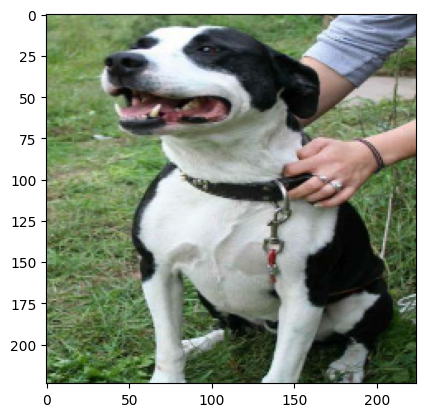

In [63]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(next(iterator)[0][0].numpy().astype(np.int32))

In [73]:
next(iterator)[0][0].numpy().ndim

3

In [78]:
from tensorflow.image import flip_left_right, adjust_brightness, adjust_contrast
def augment(image):
  image = tf.io.read_file(file_path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, (128, 128))
  image = flip_left_right(image)
  image = adjust_brightness(image, delta=0.1)
  image = adjust_contrast(image, contrast_factor=1.75)

  return (image)

train_dataset = train_dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

iterator = iter(train_dataset)

NameError: in user code:

    File "/tmp/ipykernel_14130/2805383766.py", line 3, in augment  *
        image = tf.io.read_file(file_path)

    NameError: name 'file_path' is not defined


In [ ]:
plt.imshow(next(iterator)[0][0].numpy().astype(np.int32))

In [ ]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
train_dataset

In [ ]:
from tensorflow.keras.metrics import *

metrics = ['accuracy', Precision(), Recall(), AUC()]

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

my_model.compile(loss=BinaryCrossentropy(),
                 optimizer=Adam(learning_rate=0.001),
                 metrics=metrics)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=3, monitor='val_loss')

In [ ]:
my_model.fit(train_dataset, epochs=1000,
             validation_data=val_dataset,
             callbacks=[es])